In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from experiments.overall_plots.sensitivity_utils import load_all_results, matched_main_effects

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})
sns.set_theme(style="whitegrid")

In [ ]:
DATASETS = {
    "FINDHR": "FINDHR", "FINDHRLIST": "FINDHRLIST", "MQ2007": "MQ2007", "MQ2007 List": "MQ2007LIST",
    "MQ2008": "MQ2008", "MQ2008 List": "MQ2008LIST", "YAHOO": "YAHOO", "WEB": "WEB"}
MODELS = {
    "RuleTreeRank": "rtr_query_model_selection.json",
    "Mix-RuleTreeRank": "mix_rtr_query_model_selection.json",
}
CANDIDATE_FEATURES = ["feature_diff", "sdt_depth", "pdt_depth", "dist_objective", "n_neighbors"]

In [6]:

results = load_all_results(DATASETS, MODELS)

active_features = [
    feature
    for feature in CANDIDATE_FEATURES
    if feature in results.columns and results[feature].nunique(dropna=False) > 1
]

main_summary_robust = matched_main_effects(results, active_features)

In [7]:
main_summary_robust["feature"] = main_summary_robust["feature"].replace({
    "sdt_depth": "SDT Depth",
    "pdt_depth": "PDT Depth",
    "dist_objective": "PDT target",
    "feature_diff": "F. difference ",
    "n_neighbors": "Neighbors"
})

/tmp/ipykernel_1172800/1885835992.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(main_summary_robust["feature"].tolist(), fontsize=13)


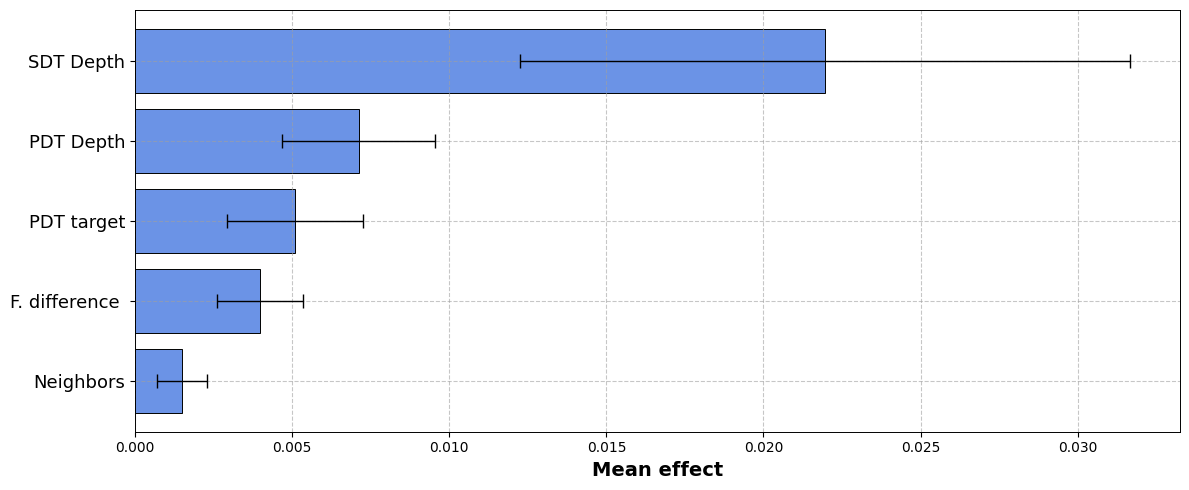

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(data=main_summary_robust, x="mean_direction", y="feature", ax=ax, edgecolor="Black", linewidth=0.7)
ax.errorbar(main_summary_robust["mean_direction"], main_summary_robust["feature"], xerr=main_summary_robust["ci95_direction"],
           fmt="none", ecolor="Black", elinewidth=1, capsize=5)
ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.6, color="#a0a0a0")
ax.set_yticklabels(main_summary_robust["feature"].tolist(), fontsize=13)
ax.set_xlabel("Mean effect", fontsize=14, fontweight="bold")
ax.set_ylabel("", fontsize=14)

for spine in ax.spines.values():
    spine.set_edgecolor('Black')
    spine.set_linewidth(0.7)

plt.tight_layout()
plt.savefig("pdfs/sensitivity.pdf", bbox_inches="tight", transparent=True)
plt.show()